<a href="https://colab.research.google.com/github/brucnsilva/topicos-de-big-data-em-phyton-pub/blob/main/versao_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

url = "https://raw.githubusercontent.com/brucnsilva/topicos-de-big-data-em-phyton-pub/main/planilha_filtrada_base_municipal.csv"

df = pd.read_csv(
    url,
    sep=";",
    encoding="latin-1"
)

df.head()

,ï»¿fmun,ano,mes,regiao,roubo_veiculo,furto_veiculos,trafico_drogas,recuperacao_veiculos
0,Angra dos Reis,2014,1,Interior,8,18,12,9
1,AperibÃ©,2014,1,Interior,0,0,0,0
2,Araruama,2014,1,Interior,9,16,4,4
3,Areal,2014,1,Interior,0,0,0,0
4,ArmaÃ§Ã£o dos BÃºzios,2014,1,Interior,2,9,10,2


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df["total_veiculos"] = df["roubo_veiculo"] + df["furto_veiculos"]

In [7]:
x = df["trafico_drogas"].values

y = df["total_veiculos"].values

coeficiente_angular, intercepto = np.polyfit(x, y, 1)

print("Coeficiente angular:", coeficiente_angular)
print("Intercepto:", intercepto)

y_pred = coeficiente_angular * x + intercepto

correlacao = df["trafico_drogas"].corr(df["total_veiculos"])

print("Correlação:", correlacao)

Coeficiente angular: 7.815608559710269
Intercepto: -36.968175341199355
Correlação: 0.8200657027877952


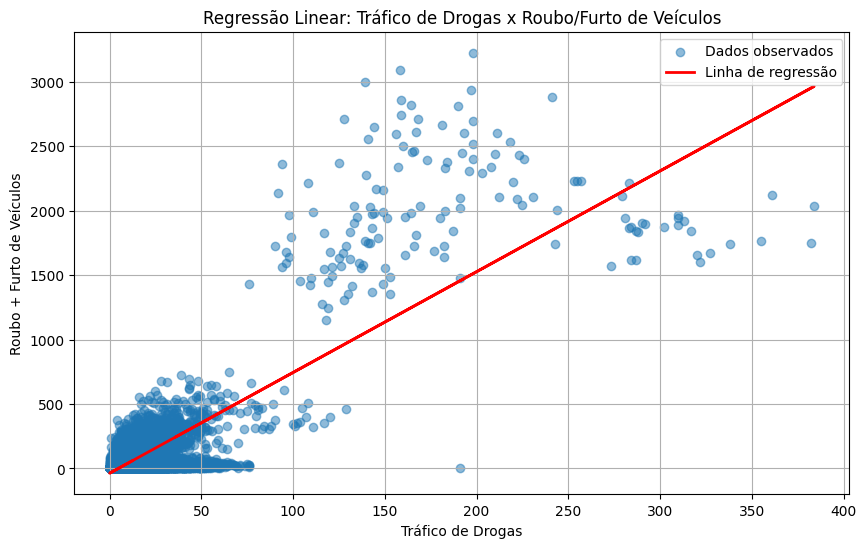

In [8]:
plt.figure(figsize=(10,6))

plt.scatter(x, y, alpha=0.5, label="Dados observados")

plt.plot(
    x,
    y_pred,
    color="red",
    linewidth=2,
    label="Linha de regressão"
)

plt.xlabel("Tráfico de Drogas")
plt.ylabel("Roubo + Furto de Veículos")
plt.title("Regressão Linear: Tráfico de Drogas x Roubo/Furto de Veículos")

plt.legend()
plt.grid(True)
plt.show()

In [9]:
import numpy as np
import matplotlib.pyplot as plt

df["total_veiculos"] = df["roubo_veiculo"] + df["furto_veiculos"]

distribuicao = df.groupby("regiao")["total_veiculos"].sum()

regioes = distribuicao.index.values
frequencias = distribuicao.values

freq_relativa = frequencias / np.sum(frequencias) * 100

freq_acumulada = np.cumsum(frequencias)

freq_rel_acumulada = np.cumsum(freq_relativa)

tabela_freq = pd.DataFrame({
    "Região": regioes,
    "Frequência Absoluta (f)": frequencias,
    "Frequência Relativa (%)": np.round(freq_relativa, 2),
    "Frequência Acumulada (F)": freq_acumulada,
})

print("\nDistribuição de Frequência:\n")
print(tabela_freq)


Distribuição de Frequência:

               Região  Frequência Absoluta (f)  Frequência Relativa (%)  \
0  Baixada Fluminense                   182476                    30.23   
1             Capital                   289794                    48.01   
2     Grande NiterÃ³i                    78061                    12.93   
3            Interior                    53280                     8.83   

   Frequência Acumulada (F)  
0                    182476  
1                    472270  
2                    550331  
3                    603611  


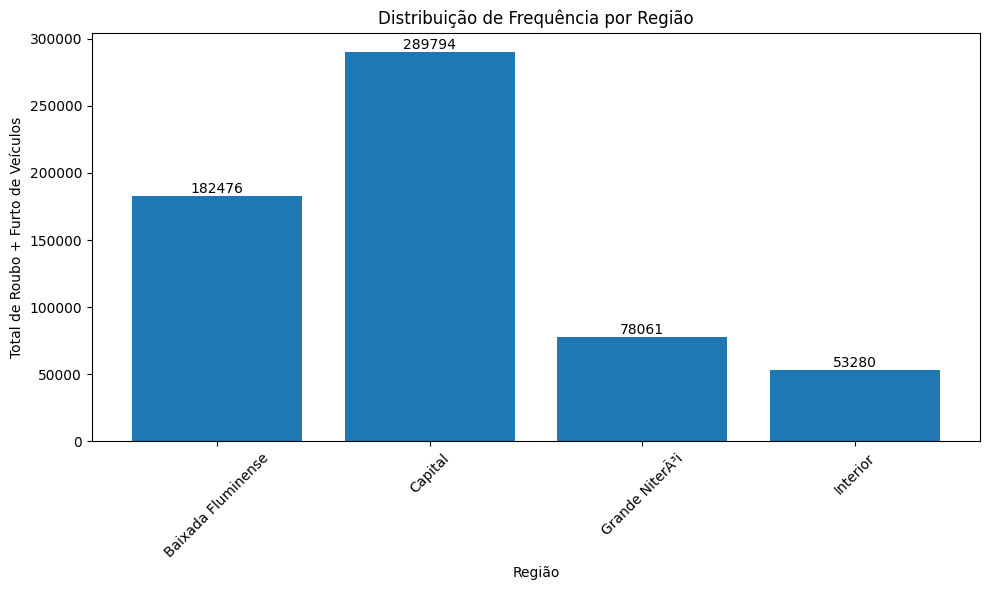

In [10]:
plt.figure(figsize=(10,6))

plt.bar(regioes, frequencias)

plt.title("Distribuição de Frequência por Região")
plt.xlabel("Região")
plt.ylabel("Total de Roubo + Furto de Veículos")

for i, valor in enumerate(frequencias):
    plt.text(i, valor, str(valor), ha='center', va='bottom')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

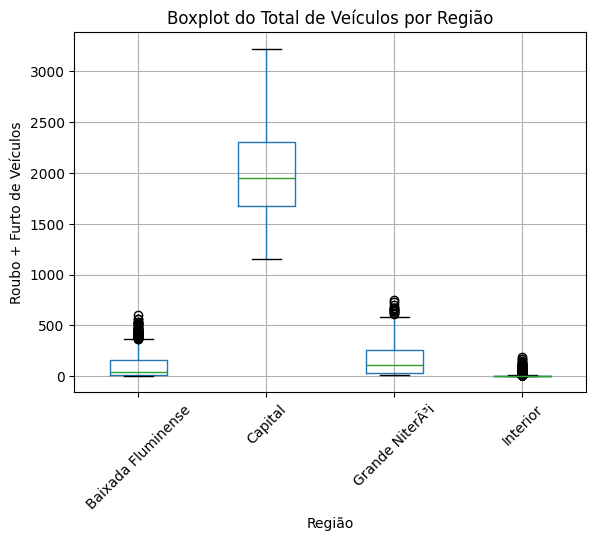

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

df.boxplot(
    column="total_veiculos",
    by="regiao",
    grid=True
)

plt.title("Boxplot do Total de Veículos por Região")
plt.suptitle("")
plt.xlabel("Região")
plt.ylabel("Roubo + Furto de Veículos")
plt.xticks(rotation=45)

plt.show()